<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# CP101: Lab 6 - Census Data, Cleaning and Joining

In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("CP101_LAB06.ipynb")

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Learning Objectives

By the end of this lab you will be able to:

1. Place a census tract in the Census Bureau's geographic hierarchy, and say where each
   Census product stops publishing.
2. Build an 11-character tract `GEOID` from its state, county and tract codes, and explain
   why storing it as a number destroys it.
3. Read a `GEO_ID`, identify which geography its summary level names, and say why a fixed
   slice is unsafe.
4. Inspect an unfamiliar dataset and identify data quality problems that a null check will
   not catch.
5. Read the American Community Survey's coded values and say what each one means.
6. Clean a dataset with `pandas`: duplicates, missing values, coded values, and date and
   time fields.
7. Join two datasets on a shared key, and verify that the join did what you expected.
8. Build a bar chart in `matplotlib` and a box plot in `seaborn`.
9. Request ACS data from the Census API, and supply the key through a `getpass` prompt on
   DataHub rather than typing it into a cell.
10. Inspect a GeoDataFrame, join TIGER geometry to ACS attributes on the `GEOID`, and
    draw a choropleth that shows which tracts have no estimate.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## How to work

Run every cell in order. When you reach a **Try it Out**, write your answer before you run
the cell below it. The questions are worth more to you than the code is.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## The data

Three files ship with this notebook, all in `data/raw/`. That folder is read-only: your
cleaning happens in memory, and the file on disk stays as it was.

**`alameda_tracts23.csv`** holds 379 census tracts in Alameda County, from the 2023
American Community Survey 5-year estimates. One row per tract, with `population` and
`median_household_income`.

**`tl_2023_06_tract.zip`** is the Census Bureau's TIGER/Line 2023 tract geometry for
all of California. You meet it in Part VI.

**`berkeley_survey_data.csv`** holds responses from a survey of Berkeley residents about
food options in their neighborhood.

> **This survey is synthetic.** It was generated for this lab. The respondent identifiers
> run `RESP0001` upward and nobody was actually asked anything. Its tract codes were
> recorded against an older tract list, which is deliberate and is the point of Part III.
> Nothing you find in it is a finding about Berkeley, and your write-up should not claim
> otherwise.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Part I. Census geography and the codes that carry it

Both files in this lab identify places with codes rather than names. Lab 5 introduced the
hierarchy and built a tract `GEOID` from its parts. This part is the full picture: what
the Census Bureau will and will not publish at each level, and the two ways an identifier
gets silently destroyed before you ever reach a join.

### The geographic hierarchy

Census geographies nest. A larger unit contains smaller ones, and the smaller ones tile the
larger one exactly.

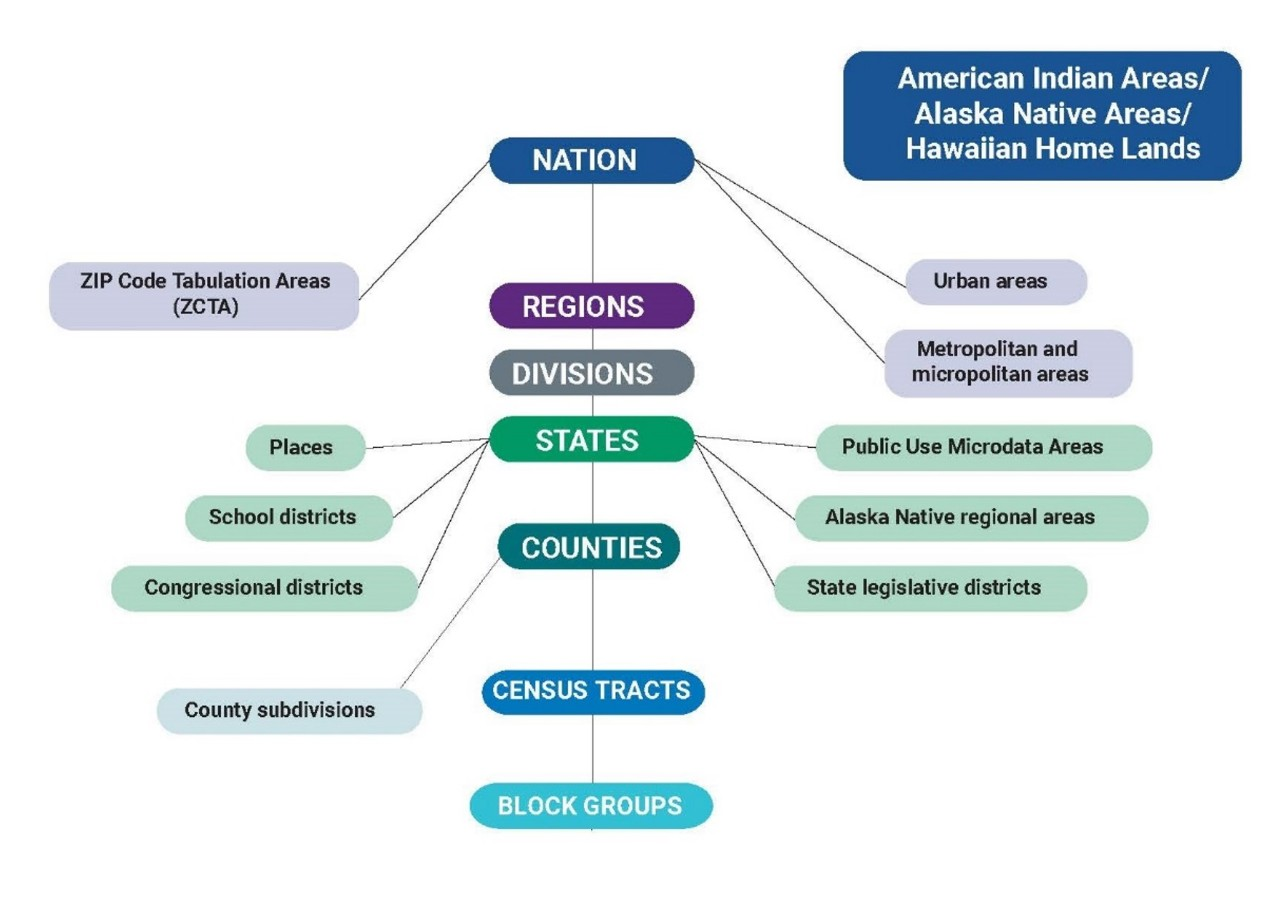

<p><em>Image source: census.gov</em></p>

The spine of that diagram runs Nation, State, County, Census Tract, Block Group, Block. The
Bureau draws census tracts to hold between 1,200 and 8,000 people, aiming for about 4,000,
and block groups to hold between 600 and 3,000.

Other geographies sit off to the side of that spine rather than inside it: places (cities
and towns), school districts, congressional districts, and **ZCTAs**. A ZCTA, or ZIP Code
Tabulation Area, is the Bureau's approximation of a ZIP code, assembled out of census
blocks. It is not a USPS ZIP code. A ZIP code is a set of delivery routes, not an area with a
boundary, so a ZCTA and the ZIP code with the same five digits do not cover exactly the
same ground.

`alameda_tracts23.csv` sits at the tract level: 379 rows, one per tract, every one of them
nested inside county `001` inside state `06`.

### Where each product stops publishing

"Which geographies can I get this for?" has a different answer for each Census product.

| Product | Smallest geography published |
| --- | --- |
| Decennial Census | Block |
| ACS 5-year Detailed Tables (the `B` tables, like `B01003`) | Block group |
| ACS 5-year Subject Tables (`S`) and Data Profiles (`DP`) | Census tract |
| ACS 1-year estimates, any table | Areas of 65,000 people or more |

Two consequences are worth carrying with you. There is no ACS 1-year tract data anywhere,
in any table, because no tract holds 65,000 people. And block-level numbers come only from
the decennial census, so a question about ACS income at the block level has no answer at
all.

This lab uses ACS 5-year estimates at the tract level, which every 5-year table type
publishes.

### FIPS codes

**FIPS** stands for Federal Information Processing Series, formerly Federal Information
Processing Standards, and you will see both expansions. FIPS codes identify states,
counties, cities and towns, and Native American areas, and they nest the same way the
geographies do.

* Texas is state `48`
* Harris County inside Texas is county `201`
* So Harris County is `48201` nationwide

The nesting is what makes the full code unique. County `001` exists in almost every state,
and only `06001` is Alameda County. County codes were assigned alphabetically within each
state using odd numbers only, so Alameda is `001`, Alpine is `003`, Amador is `005`, and
California's 58 counties run `001` to `115`; the even numbers were left free for counties
created later. Treat the ordering as a convenience rather than something to compute with,
and **tract codes are not alphabetical at all**, because tracts are numbered rather than
named.

### GEOIDs

A **GEOID** is the full identifier for one geographic area, built by joining the codes of
everything it nests inside.

| Area type | Structure | Length | Example in Alameda County |
| --- | --- | --- | --- |
| State | `STATE` | 2 | `06` |
| County | `STATE` + `COUNTY` | 5 | `06001` |
| Census tract | `STATE` + `COUNTY` + `TRACT` | 11 | `06001400100` |
| Block group | `STATE` + `COUNTY` + `TRACT` + `BG` | 12 | `060014001001` |

Reading `060014001001` apart: `06` is California, `001` is Alameda County, `400100` is
Census Tract 4001.00, and the final `1` is Block Group 1 within that tract.

The GEOID is how a table of numbers gets attached to a file of shapes, and it is the key
you will join the survey on in Part III.

> #### `GEOID` is not `geoid`
> There is an unrelated idea in geodesy called the **geoid**, a model of mean sea level
> extended under the continents that elevations are measured from. Same word, nothing in
> common with the identifiers here.

### Why these codes are text and never numbers

This is a common bug in census work, and it is silent. It raises no error and prints
no warning. It just gives you the wrong answer.

California's state FIPS code is `06`. That leading zero is part of the code. Store the code
as a number and Python throws the zero away, because a number cannot begin with one.

Run the cell and watch the first character.

In [ ]:
geoid_text = '06001400100'      # Census Tract 4001, Alameda County, California
geoid_number = int(geoid_text)  # the same code, stored as a number

print('As text:  ', geoid_text, '->', len(geoid_text), 'characters')
print('As number:', geoid_number, '->', len(str(geoid_number)), 'digits')

Eleven characters became ten digits, and nothing warned you.

The same happens to every code for the states `01` Alabama through `09` Connecticut, and to
every county and tract code with a leading zero of its own. The damage does not show up
where it happens. It shows up later, at the join: no rows match, the merged table comes
back empty or half empty, and nothing points back at the `int()` that caused it.

The fix is simple. Read these columns as text and never convert them.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# The tract codes are text, not numbers. See the note below.
tracts = pd.read_csv(
    'data/raw/alameda_tracts23.csv',
    dtype={'state': str, 'county': str, 'tract': str},
)
survey = pd.read_csv('data/raw/berkeley_survey_data.csv', dtype={'tract_fid': str})

print('census tracts:', len(tracts))
print('survey rows:  ', len(survey))

### Why the `dtype=` argument is there

`pandas` will do on its own exactly what `int()` did in Part I, if you let it. `read_csv()`
looks at a column of digits and infers an integer type, and the leading zero goes with it.
Passing `dtype={'state': str, 'county': str, 'tract': str}` tells it not to.

These columns are labels that happen to be made of digits. `06` is not the number six.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Part II. What a clean null check will not catch

Start by looking at the census file the way you would look at any file you did not make.

In [ ]:
print(tracts.info())
print()
print('Missing values per column:')
print(tracts.isna().sum())
print()
print('Summary of the numeric columns:')
print(tracts[['population', 'median_household_income']].describe())

### ✏️ Try it Out

**Answer this before running anything else.**

The missing-value check just said zero missing values in every column. The summary said the
mean median household income is about **negative ten million dollars**, and the minimum is
about **negative 667 million**.

Neither can be true of clean data.

A note on reading the summary: `describe()` printed those numbers in scientific notation.
`-1.042188e+07` means move the decimal point seven places to the right, so about negative
ten million. `-6.666667e+08` means eight places, so about negative 667 million.

Write one sentence explaining what you think is going on.

*Your answer here.*

### Coded values

Here is the answer. The American Community Survey does not leave a blank when it cannot
publish a number. It writes a specific negative integer, and the Bureau calls these
**annotation values**.

The Bureau lists six. These are the four you will meet in this course:

| Value | Which column | What it means |
| --- | --- | --- |
| `-666666666` | the estimate | The estimate could not be computed, usually too few sample observations |
| `-222222222` | the margin of error | The margin of error could not be computed, for the same reason |
| `-333333333` | the margin of error | The estimate is a median that falls in an open-ended top or bottom interval |
| `-555555555` | the margin of error | The estimate is controlled, so a test for sampling variability is not appropriate |

Notice that **three of the four live in the margin of error**, which is a column this file
does not carry. You meet two of those three next week, when you need to ask whether two
tracts can actually be told apart.

Today's file carries estimates and no margins, and the only code in it is `-666666666`.
You are about to count it.

These are ordinary negative integers as far as `pandas` is concerned. `isna()`, `isnull()`
and `dropna()` all let them straight through, which is why your missing-value check came
back clean.

**This is the single most important habit in this lab: a clean null check does not mean
clean data.** Always look at the range of your numbers as well.

The Bureau's full list is in *Notes on ACS Estimate and Annotation Values*, linked at the
end of this lab.

In [ ]:
NO_ESTIMATE = -666666666

n_no_estimate = (tracts['median_household_income'] == NO_ESTIMATE).sum()
print('Tracts with no income estimate:', n_no_estimate)

# .replace() is vectorised: it walks the whole column at C speed, no loop needed.
tracts['median_household_income'] = tracts['median_household_income'].replace(
    NO_ESTIMATE, np.nan
)

print()
print('Income summary, after converting the code to a real missing value:')
print(tracts['median_household_income'].describe())
print()
print('Missing values now:', tracts['median_household_income'].isna().sum())

### Why `np.nan`, and not `0`, and not a row drop

Three choices were available.

Replacing with `0` invents an income. A tract where the Bureau could not publish a number
becomes the poorest tract in the county, and every mean and every map is wrong afterwards.

Dropping the row deletes a neighborhood. One of these six tracts holds **5,015 residents**.
They did not stop existing because the sample was too small.

`np.nan` records what is actually known: there is no number here. `pandas` then excludes it from
`mean()` and `median()` automatically, and, more importantly, it stays visible. That choice
is about to matter, because some of your survey respondents live in one of these tracts.

### Two more things hiding in this column

**Top-coding.** Look at the maximum: exactly `250001`. That is not a real median income for
any tract. The Bureau does not publish a tract median above $250,000; data.census.gov shows
such a tract as `250,000+`, and the API and the machine-readable files carry it as `250001`. Every tract at that value could have a true median of $260,000 or $600,000
and you cannot tell them apart. It is a ceiling, not a maximum, and averaging this column
understates the top of the distribution.

**Zero-population tracts.** A tract can have no residents at all. Regional parks, industrial
land and bodies of water all get tract numbers. These are real rows, not errors, but they
will distort any per-capita calculation.

Run the cell below to count both.

In [ ]:
TOP_CODE = 250001

n_top_coded = (tracts['median_household_income'] == TOP_CODE).sum()
n_empty = (tracts['population'] == 0).sum()

print('Tracts at the top-code:      ', n_top_coded)
print('Tracts with zero population: ', n_empty)
print()
print('The zero-population tracts:')
print(tracts.loc[tracts['population'] == 0, ['NAME', 'population', 'median_household_income']])

### ✏️ Try it Out: build the GEOID

Part I laid out the structure: 2 characters of state, 3 of county, 6 of tract. There it was
one code written out by hand. Here it is a whole column.

`state`, `county` and `tract` are three separate text columns. Glue them together, in that
order, into a new column called `geoid`. Because they are text, `+` concatenates rather
than adds.

Then print the first value to check it.

In [ ]:
tracts['geoid'] = ...

print(tracts['geoid'].iloc[0])

In [ ]:
grader.check("q_geoid")

Eleven characters, and the first one is a zero. That zero survived only because
`read_csv()` was told to keep these columns as text. This is the key you will join on.

### Reading a `GEO_ID`

The column you just built is a plain 11-character GEOID. Files downloaded from
data.census.gov carry a longer field called `GEO_ID`, and the two are not interchangeable:

```text
1400000US06001400100
^^^      ^^^^^^^^^^^
summary  the 11-character GEOID
level
```

The first three characters are the **summary level**, which says what kind of geography the
row describes. `140` is a census tract, `050` is a county, `040` is a state. The four zeros
after it are two further fields, the geographic variant and component, which are `0000` in
every file you will use in this course. Everything after `US` is the GEOID itself.

The summary level is there because one downloaded file can hold rows at more than one
level, and that is what makes a fixed slice unsafe. The part after `US` is 11 characters
for a tract, 5 for a county and 2 for a state. Take the last six characters as "the tract
code" and a tract row gives you `400100`, while a county row gives you `S06001`. Neither
raises an error. Check the summary level first, then decide how to slice.

### ✏️ Try it Out: split a `GEO_ID` column

The cell below holds a small sample of `GEO_ID` values, two tract rows and two county rows
mixed together, which is what a data.census.gov download often looks like.

In [ ]:
geo_sample = pd.DataFrame({
    'GEO_ID': [
        '1400000US06001400100',
        '1400000US06001420301',
        '0500000US06001',
        '0500000US06075',
    ]
})

geo_sample

Add two columns to `geo_sample`:

1. `summary_level`, the first three characters of `GEO_ID`;
2. `geoid`, everything after `US`.

Use the `.str` accessor rather than a loop. `.str[:3]` slices every value in the column, and
`.str.split('US')` splits every value into a two-item list, so `.str.split('US').str[1]`
gives you the part after the separator.

In [ ]:
geo_sample['summary_level'] = ...
geo_sample['geoid'] = ...

geo_sample['n_characters'] = geo_sample['geoid'].str.len()
geo_sample

In [ ]:
grader.check("q_summary_level")

Two lengths in one column. The only thing that told you which row was which was the summary
level sitting in front of the code.

`alameda_tracts23.csv` is all tracts, so you will not meet this today. The first time you
download a file that holds tracts and counties together, you will.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Part III. Exploring, cleaning and joining a survey

`berkeley_survey_data.csv` holds responses from a survey of Berkeley residents. Each person
rated the food options in their neighborhood, said how often they eat out, and rated how
much their neighborhood needs a "third place", meaning somewhere to spend time that is
neither home nor work.

You have not seen this file before. Start by looking at it.

In [ ]:
print(survey.info())
print()
print(survey.head())
print()
print('Rows:       ', len(survey))
print('Respondents:', survey['respondent_id'].nunique())

The row count and the respondent count are not the same number. Somebody is in here
more than once.

Before cleaning anything, look at what the categories actually contain.

In [ ]:
print(survey['frequency_eating_out'].value_counts())
print()
print(survey['food_options_rating'].value_counts().sort_index())
print()
print('Missing values per column:')
print(survey.isna().sum())

### Cleaning, in this order

Two problems, and the order matters.

**Duplicate responses.** Some people appear twice. `drop_duplicates()` with
`subset='respondent_id'` keeps one row per person. Which copy you keep is a choice, and in
this file the two choices produce different data.

**Missing tract.** Some rows have no `tract_fid`. A response with no location cannot be
joined to census data.

Print the row count after each step. Counting rows before and after every cleaning
operation is the habit that catches this kind of mistake, and **watch the second number**.
If it surprises you, that is the exercise working.

### ✏️ Try it Out: which copy do you keep?

Build `survey_clean` in two steps, printing the row count after each:

1. `drop_duplicates()` on `subset='respondent_id'` with `keep='first'`
2. `dropna()` on `subset=['tract_fid']`

Then build `alternative` exactly the same way, but with `keep='last'`.

**Before you run it, predict:** will the two row counts differ, and at which step?

In [ ]:
print('starting rows:', len(survey))

survey_clean = ...
print("after keep='first':", len(survey_clean))
survey_clean = ...
print('after dropna:      ', len(survey_clean))

alternative = ...
print("after keep='last': ", len(alternative))
alternative = ...
print('after dropna:      ', len(alternative))

In [ ]:
grader.check("q_keep")

### What just happened

Both `drop_duplicates()` calls returned **100 rows**. At that step the two paths look
identical and nothing warns you that they are not.

Then `dropna()` removed **10 rows from one of them and none from the other**.

Here is why. Every duplicate in this file is a second copy sitting at the end, and in every
one of those second copies the `tract_fid` is blank. So `keep='first'` keeps the copy that
still has a location, and `keep='last'` keeps the copy that lost it.

`keep='first'` is not defensible here because the choice does not matter. It is defensible
because the first copy is the one that still knows where the respondent lives.

The cost is not hypothetical. You are about to join this to the census file, and you will
carry **86 matched responses** instead of **79**.

### Dates and times

The survey stores the date and the time in two separate text columns. Neither one is a date
as far as `pandas` is concerned; they are both just strings.

`pd.to_datetime()` turns them into a real datetime, which unlocks the `.dt` accessor.
`.dt` gives you the parts of a datetime: `.dt.hour`, `.dt.year`, `.dt.day_name()` and many
more. Subtracting two datetimes gives you a duration.

In [ ]:
survey_clean = survey_clean.copy()
survey_clean['submitted_at'] = pd.to_datetime(
    survey_clean['submission_date'] + ' ' + survey_clean['submission_time']
)

print(survey_clean[['respondent_id', 'submitted_at']].head())
print()
print('First response:', survey_clean['submitted_at'].min())
print('Last response: ', survey_clean['submitted_at'].max())

### Joining the survey to the census data

Now put them together. Each survey response carries a `tract_fid`, and each census row
carries the `geoid` you built in Part II.

Those are not yet the same thing. `tract_fid` is the 6-character tract code on its own,
and `geoid` is the full 11-character code. Every respondent in this survey is in Alameda
County, so the state and county parts are the same constant for all of them, and you can
build the full key.

It would be easier to join on the bare 6-character `tract` column instead. Do not. You
built an 11-character key in Part II because that is what identifies a tract uniquely in the
whole country, and joining on the short code here would undo that.

`pd.merge()` has a `how` argument that decides which rows survive:

| `how` | Keeps |
| --- | --- |
| `'inner'` | Only rows where the key appears in **both** tables |
| `'left'` | Every row from the left table, with blanks where there was no match |
| `'right'` | Every row from the right table |
| `'outer'` | Every row from both |

Start with an inner join, and **count the rows**.

In [ ]:
# Every respondent is in Alameda County: state 06, county 001.
survey_clean['geoid'] = '06' + '001' + survey_clean['tract_fid']

merged = survey_clean.merge(tracts, on='geoid', how='inner')

print('survey rows in: ', len(survey_clean))
print('rows out:       ', len(merged))
print('rows lost:      ', len(survey_clean) - len(merged))

### ✏️ Try it Out: never accept a join without checking it

The inner join silently discarded every row it could not match. The row counts above are
the only reason you know it happened at all.

Run the same join with `how='left'` and `indicator=True`. The `_merge` column it adds tells
you, row by row, which table each row came from. Then list the tract codes that failed to
match, and compare them against the codes the census file actually has.

In [ ]:
check = survey_clean.merge(tracts, on='geoid', how='left', indicator=True)

print(check['_merge'].value_counts())
print()

unmatched = sorted(check.loc[check['_merge'] == 'left_only', 'tract_fid'].unique())
print('Survey tract codes with no census match:', unmatched)
print()

berkeley_codes = sorted(tracts.loc[tracts['tract'].str.startswith('42'), 'tract'].unique())
print('Census tract codes in the same range:')
print(berkeley_codes[:14])

### What went wrong

Line the two lists up and the pattern appears.

The survey uses `420300` and `420400`. The census file has `420301`, `420302`, `420401` and
`420402` instead. Those `01` and `02` endings are what a tract looks like after it has been
**split**, which the Bureau does when a tract's population has grown past the range tracts
are designed for.

This is not a story invented for the exercise. The Bureau's 2010 to 2020 tract relationship
file for California records that Census Tract 4203 became 4203.01 and 4203.02, and Census
Tract 4204 became 4204.01 and 4204.02, for the 2020 Census. The survey is using the 2010
codes. Both files are about Berkeley. Both use codes that look identical in format. They
refer to different pieces of ground, because they were drawn in different **vintages**.

This is why you check which year's boundaries your data uses before you join anything.

**Questions to answer in your write-up:**

1. If you had run only the inner join and gone straight to plotting, what would you have
   concluded, and how would you have known you were wrong?
2. The unmatched responses are not scattered at random. They are every respondent from two
   specific tracts. Why does that make dropping them worse than dropping the same number of
   rows chosen at random?
3. Name one thing you could do to recover these responses rather than discard them.
   There is a real answer. The Bureau's tract relationship files list which 2020 tracts each
   2010 tract became and how much land area each piece covers, and IPUMS NHGIS publishes
   crosswalks built on them with population-based weights. Either would let you assign
   these respondents to a 2020 tract with a stated share of uncertainty. That is more work
   than today allows, but "unrecoverable" is not the same as "not worth recovering".

For the rest of this lab you work with the **86 matched responses**, because that is what
can be joined today. Every chart from here on describes those tracts only, and your write-up
should say so.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Part IV. Two plots, and the tracts with no income estimate

Before plotting, one thing to check. Some of your matched respondents live in a tract whose
income estimate you turned into `np.nan` back in Part II. They are still here, they still
answered the survey, and they were counted: their tract has a population. What the ACS
could not publish is a median household income for that tract, because the sample there
was too small to support one.

In [ ]:
print('Matched responses:                    ', len(merged))
print('Distinct tracts they live in:         ', merged['geoid'].nunique())
print('Responses with no tract income:       ', merged['median_household_income'].isna().sum())
print()
print('Missing ratings before we treat this as numeric:',
      merged['food_options_rating'].isna().sum())

### Four groups, and a summary that does not exist

The obvious next move is to take the **mean rating** of each group and draw four bars. Do not.
A 1 to 5 rating is **ordinal**: the answers have an order, but the gaps between them are not
measured. Nothing in the survey says the distance from `1` to `2` is the distance from `4` to
`5`, so adding the numbers up and dividing gives you a figure with no unit and no meaning,
however confidently it prints.

What the scale does support is **counting**, and a median, which is just the middle answer.
So: one panel per group, every bar starting at zero on the same axis, and the group size
written above each panel because the four groups are not the same size.

*Percentages, not counts, because a group of 19 and a group of 23 cannot be compared bar for
bar otherwise.*

### Grouping, in one paragraph

The chart below uses `.groupby()`, which you have not met yet. It splits a table by the
values in one column and applies a summary to each group. `merged.groupby(
'frequency_eating_out')['food_options_rating'].mean()` means: for each distinct value of
`frequency_eating_out`, take the `food_options_rating` values of the rows that share it and
average them. The result is one number per category. `.reindex(frequency_order)` then puts
the categories in an order that makes sense rather than alphabetical order.

In [ ]:
frequency_order = [
    'never',
    'once weekly',
    '2-5 times a week',
    'more than five times a week',
]

# A 1 to 5 rating is ORDINAL: ordered, but not spaced. Nothing says the step from 1 to 2 is
# the same size as the step from 4 to 5, so there is no mean to take. What you can do is
# count, and compare the shape of the answers one group at a time.
counts = pd.crosstab(merged['frequency_eating_out'],
                     merged['food_options_rating']).reindex(frequency_order)
shares = counts.div(counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 4, figsize=(13, 3.9), sharey=True)

for ax, group in zip(axes, frequency_order):
    sns.barplot(x=shares.columns, y=shares.loc[group].values, color='#003262', ax=ax)
    ax.set_title(f'{group}\n{counts.loc[group].sum()} people', fontsize=10)
    ax.set_xlabel('rating given')
    ax.set_ylim(0, 45)

axes[0].set_ylabel('% of that group')
fig.suptitle('How each group rated local food options, one panel per group', fontsize=12.5)
plt.tight_layout()
plt.show()

print(counts)
print()
print('median rating per group (the middle answer, which an ordinal scale does support):')
print(merged.groupby('frequency_eating_out')['food_options_rating']
      .median().reindex(frequency_order))


### What the mean would have hidden

Read the four panels against each other, and the useful finding is a **shape**, not a level.

The people who eat out **more than five times a week** are the most divided group on the plot:
`35%` of them give the top rating and `30%` give a middle `3`, but only `4%` pick `4`. Their
answers pile up at both ends. Had you drawn mean ratings, that group would have come out at
`3.30`, the highest of the four bars, and you would have reported "the people who eat out most
are the happiest with local food" from a group where one in eight rates it the lowest possible
score.

The medians disagree with the means about which group is happiest at all. `2-5 times a week`
has the highest median, `4`, but not the highest mean; `more than five times a week` has the
highest mean and a median of `3`. Two summaries of the same 86 answers, pointing at two
different groups. That is the question you are asked in Part IV's closing questions, and this
is where it starts.

**The mean is not a small inaccuracy here. It is a number about a quantity nobody measured.**

### ✏️ Try it Out: group the tracts by income

Sort the respondents into three income bands, plus one more group for the people whose
tract has no estimate at all.

Compute the cutoffs on **tracts, not on responses**. A tract with twelve respondents in it
would otherwise count twelve times toward the cutoff, and you would be measuring how many
people answered rather than how incomes are distributed.

1. Take one row per tract, and pull `median_household_income` from it.
2. Use `.quantile(1/3)` and `.quantile(2/3)` to get the two cutoffs.
3. Assign `'Lower income'`, `'Middle income'` and `'Higher income'` with `.loc`.
4. Then handle the tracts with no estimate.

Step 4 is not optional tidying. A comparison against a missing value is always `False`, so
those rows fall through all three `.loc` assignments and keep whatever the column started
as. Give them their own label.

In [ ]:
tract_incomes = merged.drop_duplicates(subset='geoid')['median_household_income']

lower_cut = ...
upper_cut = ...
print(f'cutoffs: {lower_cut:,.0f} and {upper_cut:,.0f}')

merged['income_group'] = 'Unassigned'
merged.loc[..., 'income_group'] = 'Lower income'
merged.loc[..., 'income_group'] = 'Middle income'
merged.loc[..., 'income_group'] = 'Higher income'

# A comparison against NaN is always False, so these rows were never touched above.
merged.loc[..., 'income_group'] = 'No income estimate'

print(merged['income_group'].value_counts())

In [ ]:
grader.check("q_groups")

### Seven respondents with no tract income estimate

**Seven of your 86 respondents live in a tract the ACS could not produce an income estimate
for.** They were not dropped, and they were not quietly labelled `'Lower income'` by
accident. They have their own category, and on the plot below they get their own box.

That is the consequence of choosing `np.nan` in Part II. Had you replaced `-666666666` with `0`,
these seven would be sitting in `'Lower income'` right now, dragging its mean down, and
nothing in the output would look wrong.

In [ ]:
group_order = ['Lower income', 'Middle income', 'Higher income', 'No income estimate']

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=merged,
    x='income_group',
    y='food_options_rating',
    order=group_order,
    ax=ax,
    color='#FDB515',
)
ax.set_xlabel('')
ax.set_ylabel('Rating of local food options (1 to 5)')
ax.set_title('Food options rating by tract income group, 86 Berkeley responses')
plt.tight_layout()
plt.show()

print(merged.groupby('income_group')['food_options_rating'].agg(['count', 'mean', 'median'])
      .reindex(group_order).round(2))

### ✏️ Try it Out: the closing questions

Answer these in your write-up.

1. The group means run from 2.75 to 3.58, but three of the four medians are identical at
   3.0. What is the difference between those two summaries, and which one would you put in
   front of a city council?
2. You have 86 responses across 13 tracts, after losing 14 to a vintage mismatch, from a
   survey that is synthetic to begin with. What would you need before treating any of this
   as a finding?
3. One of your 13 tracts sits at the top code of $250,001 and supplies **12 of the 31**
   responses in the `'Higher income'` group. What does that do to that group's label?
4. Seven respondents live in a tract with no income estimate. Argue for showing that box on
   the plot, then argue against it. Which do you actually believe?

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />


## Part V. Where this table came from: the Census API

`alameda_tracts23.csv` was downloaded from the Census Bureau. This part shows you how to
request it yourself, so that a different county, a different year or a different variable
is a change to one line rather than another trip through a download form.

An **API**, or Application Programming Interface, is a structured way for one program to
ask another for data. You send a request naming what you want, and the service returns that
and nothing else. The request lives in your code, so it records which product, which
variables, which geography and which year you asked for, and anyone reading the notebook
can run it again.

### Getting a key

The Census Data API requires a key, which is free and takes about a minute.

1. Open the Bureau's [key request form](https://api.census.gov/data/key_signup.html), which
   is also linked from the [developers page](https://www.census.gov/data/developers.html).
2. Enter your email address and accept the terms of service.
3. The Bureau emails you the key with an activation link. Activate it before you use it.

A request sent without a key does not fail loudly. The API answers with a web page titled
*Missing Key* instead of data, and the code below checks for that.

**This lab runs without one.** Everything below falls back to the file that
ships with the notebook, so skip the key if you do not want one today.

### Never type a key into a cell

The one thing not to do is this:

```python
CENSUS_API_KEY = "a1b2c3d4e5f6"   # do not do this
```

A notebook is a file you share. On DataHub it sits on a server you do not control, it goes
to Gradescope as your submission, and it may end up in a repository or a screenshot. A key
pasted into a cell goes everywhere the notebook goes, and it stays in the saved output even
after you delete the line, because the value is sitting in the cell's stored result. This
is how keys end up in public repositories.

**On DataHub the workflow is `getpass`.** `getpass.getpass()` asks the kernel for a secret.
In JupyterLab that appears as a masked input box under the cell: what you type is not
shown, is not written into the notebook file, and is not stored in the cell's output. The
key lives in the kernel's memory and nowhere else. Restart the kernel and it is gone, which
is why the prompt comes back every session. That is the point, not an inconvenience: a
secret that is never written down cannot be leaked by the file.

Two things to know before you run the cell.

* **"Run All" pauses at the prompt** and waits for you. Type the key, or press Enter with
  nothing to skip it and use the shipped file.
* On your own laptop you might instead keep the key in an environment variable named
  `CENSUS_API_KEY`, set once in your shell. The first line of the cell checks for one, so
  the same notebook works there too. On DataHub, leave that to the prompt.

The `try` / `except` around the prompt has a specific job. `getpass` needs somewhere to
ask, and inside the autograder there is no interactive prompt, so the call raises instead
of waiting. Catching it lets the same notebook run on DataHub and in the autograder without
edits.

In [ ]:
import getpass
import os

# A laptop with the key exported as an environment variable. On DataHub this is None.
CENSUS_API_KEY = os.environ.get('CENSUS_API_KEY')

if CENSUS_API_KEY is None:
    try:
        # DataHub: a masked prompt appears below this cell. Nothing you type is saved.
        entered = getpass.getpass('Census API key (press Enter to skip): ')
        CENSUS_API_KEY = entered.strip() or None
    except Exception:
        # No interactive prompt available, which is what the autograder looks like.
        CENSUS_API_KEY = None

print('Key available:', CENSUS_API_KEY is not None)

Notice what that cell printed: `True` or `False`, and **not the key**. Printing the key
writes it into the notebook's saved output, which undoes what the prompt just protected. To
confirm you pasted the right value, check its length or its last four characters.

Now the request itself. The Census API is a URL with four things in it:

| Part of the URL | What it says |
| --- | --- |
| `.../data/2023/acs/acs5` | which product: 2023 ACS 5-year estimates |
| `get=NAME,B01003_001E,B19013_001E` | which variables: name, total population, median household income |
| `for=tract:*` | which geography: every tract |
| `in=state:06&in=county:001` | inside which parent: Alameda County, California |

`B01003_001E` and `B19013_001E` are ACS **variable codes**. `B01003` is the total
population table and `B19013` is median household income; `_001` is the first line of the
table, and `E` marks the estimate. Swap it for `M` and you have the margin of error,
`B19013_001M`. The Bureau's label for `B19013_001E` is median household income "in the past
12 months (in 2023 inflation-adjusted dollars)": a 5-year estimate pools five years of
responses and expresses them all in the final year's dollars. The Bureau publishes the full
list of codes for each year at
[api.census.gov/data/2023/acs/acs5/variables.html](https://api.census.gov/data/2023/acs/acs5/variables.html).

In [ ]:
import json
import urllib.request


def fetch_alameda_tracts(api_key):
    """Fetch 2023 ACS 5-year population and median household income for Alameda tracts.

    Every column comes back as text, because the geography codes are labels and the
    leading zeros have to survive. See Part I.
    """
    url = (
        'https://api.census.gov/data/2023/acs/acs5'
        '?get=NAME,B01003_001E,B19013_001E'
        '&for=tract:*&in=state:06&in=county:001'
        f'&key={api_key}'
    )
    with urllib.request.urlopen(url, timeout=30) as response:
        content_type = response.headers.get('Content-Type', '')
        body = response.read()

    # A missing or rejected key does not produce an HTTP error. The API sends back an
    # ordinary web page, so check what arrived before trying to read it as data.
    if 'json' not in content_type:
        raise RuntimeError('the API returned a web page instead of data; '
                           'the key was probably missing or rejected')

    # The data is a list of lists, and the first list is the header row.
    rows = json.loads(body)
    return pd.DataFrame(rows[1:], columns=rows[0])


api_tracts = None

if CENSUS_API_KEY:
    try:
        api_tracts = fetch_alameda_tracts(CENSUS_API_KEY)
        print('Rows from the API:', len(api_tracts))
        print(api_tracts.head())
    except Exception as error:
        print('The API call did not succeed:', error)
        print('Carrying on with the file that ships with this notebook.')
else:
    print('No key, so no API call. The shipped file is already loaded as `tracts`.')

### Check the API against the file

If you did make a call, do not assume the two agree. Check, the same way you counted rows
after the join.

The comparison below rebuilds the GEOID from the API's own `state`, `county` and `tract`
columns, then asks whether the set of tracts matches the file, and whether the population
numbers agree.

In [ ]:
if api_tracts is not None:
    api_tracts['geoid'] = (
        api_tracts['state'] + api_tracts['county'] + api_tracts['tract']
    )
    api_population = pd.to_numeric(api_tracts['B01003_001E'])

    same_tracts = set(api_tracts['geoid']) == set(tracts['geoid'])
    print('Same set of tracts as the shipped file:', same_tracts)
    print('Tracts from the API:  ', len(api_tracts))
    print('Tracts in the file:   ', len(tracts))
    print('Total population, API: ', f'{api_population.sum():,}')
    print('Total population, file:', f"{tracts['population'].sum():,}")
else:
    print('Nothing to compare. Run the cell above with a key to try this.')

Two things to carry out of this part.

**The sentinel is in the API too.** `-666666666` is not an artefact of how this CSV was
made. The API returns the same value, as text, and data.census.gov shows the same tract
with a dash and a footnote. Everything you did in Part II you would have to do again here.

**A request in code is reproducible; a download is not.** The function above names its
product, its variables, its geography and its year. Change `2023` to `2022` and you have
last year's table. Change `county:001` to `county:075` and you have San Francisco.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />


## Part VI. Tract geometry and a first map

Everything so far has been a table, where a tract is a row with a code on it. A tract is
also a piece of ground.

Census data arrives in **two separate pieces**:

* the **attributes**, the numbers, from the ACS: `alameda_tracts23.csv`, which you have;
* the **geometry**, the shapes, from the Bureau's TIGER/Line files.

The `geoid` you built in Part II is what connects them, and Lab 7 is where you connect
them. Today's goal is smaller: load the shapes on their own and see what a GeoDataFrame is.

**TIGER** stands for Topologically Integrated Geographic Encoding and Referencing. The
Bureau publishes one file per state per year, and `geopandas` reads the zipped shapefile
directly without you unzipping anything.

> **Match the vintage.** These are 2023 ACS attributes, so they need 2023 TIGER geometry.
> Pairing one year's numbers with another year's boundaries is exactly the failure you
> diagnosed in Part III, where a survey coded to older tracts lost 14 respondents to a join
> that reported nothing wrong. Here the same mistake would quietly drop tracts off a map.

In [ ]:
# Source: https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_06_tract.zip
#
# The file ships with this notebook rather than downloading, because it is about 32 MB and a
# whole lab section fetching it at once over the same wifi is not a good use of the hour.
# The URL is here so you can get a different year yourself later.
california_tracts = gpd.read_file('data/raw/tl_2023_06_tract.zip')

print('Tracts in California:', len(california_tracts))
print('CRS:                 ', california_tracts.crs)
print('Columns:             ', list(california_tracts.columns))

### What a GeoDataFrame is

`gpd.read_file()` returned a **GeoDataFrame**. It is a `pandas` DataFrame with one extra
column, called `geometry`, whose values are shapes rather than numbers or text. Each shape is
the list of coordinates that traces one tract's boundary.

Three things follow, and they are most of what you need today.

1. **Everything from Parts I to IV works on it unchanged.** `.loc[]`, Boolean masks,
   `.merge()`, `.value_counts()`, `.groupby()` and `.isna()` do not care that one column
   holds polygons.
2. **GeoPandas adds methods that read the `geometry` column.** `.plot()` draws it,
   `.geom_type` says what kind of shape each row holds, and `.total_bounds` gives the
   rectangle that contains every shape.
3. **`.crs` names the coordinate reference system**, which says what the coordinate numbers
   mean. That is Wednesday's class activity and most of Lab 7. Today you only need to know
   that it exists and that GeoPandas carried it in from the file.

Look at the object before doing anything with it.

In [ ]:
print('Type:                ', type(california_tracts).__name__)
print('Geometry column name:', california_tracts.geometry.name)
print()
print('Shape types in the geometry column:')
print(california_tracts.geom_type.value_counts())
print()

first_shape = california_tracts.geometry.iloc[0]
print('The first geometry, written out as text and cut off after 70 characters:')
print(str(first_shape)[:70] + ' ...')
print()

minx, miny, maxx, maxy = california_tracts.total_bounds
print(f'Smallest and largest x: {minx:.2f} to {maxx:.2f}')
print(f'Smallest and largest y: {miny:.2f} to {maxy:.2f}')

california_tracts[['GEOID', 'NAME', 'COUNTYFP', 'geometry']].head(3)

Read that output top to bottom.

**Two shape types.** Most tracts are a single `Polygon`. Ten are `MultiPolygon`: one row
holding several separate pieces, which happens when a tract includes an island or is cut in
two by water. Both are ordinary values in the `geometry` column, and the table view shows
them the way it shows any long value, as text truncated to fit.

**The coordinates are degrees.** The x values run from about -124.5 to -114.1 and the y
values from 32.5 to 42.0. Those are longitude and latitude, and they are exactly the
extent of California. That is what `EPSG:4269` printed above means: the numbers in this
file are degrees of longitude and latitude on the NAD83 datum. Next week you will see why
that is the wrong CRS for measuring anything and the right one for storing and joining.

**`COUNTYFP` is the county FIPS code from Part I**, stored as text, with the same leading
zero rules. Which means you already know how to ask this file a question.

### A `pandas` operation on a GeoDataFrame

`.groupby()` splits a table by the values in one column and applies a summary to each
group. You used it in Part IV to take a mean rating per eating-out category. Here it counts
rows per county, and the fact that those rows carry polygons changes nothing.

In [ ]:
tracts_per_county = (
    california_tracts.groupby('COUNTYFP')
    .size()
    .sort_values(ascending=False)
)

print('Counties in the file:', len(tracts_per_county))
print()
print('The five counties with the most tracts:')
print(tracts_per_county.head())
print()

# A Boolean mask on a GeoDataFrame gives back a GeoDataFrame.
bay_side = california_tracts[california_tracts['COUNTYFP'].isin(['001', '075', '081'])]
print('Alameda, San Francisco and San Mateo together:', len(bay_side), 'tracts')
print('Still a', type(bay_side).__name__)

Los Angeles County alone has 2,498 tracts, more than a quarter of the state. The count is a
plain `pandas` Series, and the masked selection is still a GeoDataFrame — the same
filter-and-merge move you used on ordinary tables in Part III works here too, and Lab 7 is
where you put it to use on this exact file.

Selecting rows by a code in a column, as you just did, is **attribute selection**. Selecting
rows by where their shapes are, "every tract that touches Berkeley", is **spatial
selection**, and that is also Lab 7.

`.plot()` with no arguments draws every row in one colour. Try it on the whole state.

In [ ]:
california_tracts.plot()
plt.title('Every census tract in California, 2023 TIGER/Line')
plt.show()

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Wrap-Up

The habits from this lab, in order of how often they will save you:

1. **Count rows before and after every cleaning step and every join.** Silent row loss is
   the most common serious error in data analysis.
2. **A clean null check does not mean clean data.** Look at the range of your numbers.
   Coded values, top-codes and sentinels all pass `isna()`.
3. **Know which copy you kept.** `keep='first'` and `keep='last'` returned the same row
   count here and different data.
4. **Codes stay as text.** Leading zeros are part of the code.
5. **Two files about the same place can still use different boundaries.** Check the vintage.
6. **Know which geography a row is.** A tract number and a county number are not
   comparable, and when a `GEO_ID` is all you have, the summary level in front of it is the
   only thing that says which you are holding.
7. **A key never goes in a cell.** On DataHub, `getpass` prompts for it and keeps it in
   kernel memory only, and a fallback lets the notebook run for somebody with no key.
8. **Be careful what you pin on a person.** You compared an individual's rating against
   their tract's median income. That is a place-level attribute attached to a person, and
   concluding something about the person from it is called the **ecological fallacy**. The
   tract median says nothing about any particular household in it.

### Going Further

* Census Bureau, [Geography Glossary](https://www.census.gov/programs-surveys/geography/about/glossary.html),
  for any geographic term in this lab you want the official definition of.
* Census Bureau, [Geocoder](https://geocoding.geo.census.gov/geocoder/geographies/onelineaddress?form).
  Type in any address, keep the default benchmark and vintage, and read the state, county
  and tract codes for it off the results. Building that GEOID by hand is the fastest way to
  make Part I stick.
* Census Bureau, *Notes on ACS Estimate and Annotation Values*, for the full list of coded
  values.
* Census Bureau, *Understanding and Using American Community Survey Data*, the official
  handbook series.
* Kyle Walker, *Analyzing US Census Data: Methods, Maps, and Models in R*, free online.
  It is written in R rather than Python, but chapters 2 and 3 cover ACS wrangling and
  margins of error in detail, and the concepts transfer directly.
* Census Bureau, [2020 Census Tract Relationship Files](https://www.census.gov/geographies/reference-files/time-series/geo/relationship-files.2020.html),
  the source for the 4203 and 4204 splits in Part III.
* Census Bureau, [Census Data API User Guide](https://www.census.gov/data/developers/guidance/api-user-guide.html),
  for everything the URL in Part V can take.

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit.

Upload your submission zip to **LAB06 - Census Data, Cleaning and Joining** on [Gradescope](https://www.gradescope.com/).

In [ ]:
grader.export(pdf=False, force_save=True, run_tests=True)